#### Hands-on 3
#### Deep Learning
#### Hamed Ahmadinia

### 1. Import libraries

In [10]:
import os
import re
import time
import math
import copy
import random
import string
import tarfile
import urllib.request
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

### 2. Reproducibility

In [11]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### 3. Download IMDB if needed

In [12]:
imdb_folder = "aclImdb"
imdb_archive = "aclImdb_v1.tar.gz"
imdb_url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

if not os.path.exists(imdb_folder):
    print("Downloading IMDB dataset...")
    urllib.request.urlretrieve(imdb_url, imdb_archive)
    print("Extracting IMDB dataset...")
    with tarfile.open(imdb_archive, "r:gz") as tar:
        tar.extractall(".")
    print("IMDB dataset ready.")
else:
    print("IMDB dataset already exists.")

Extracting IMDB dataset...
IMDB dataset ready.


### 4. Load IMDB dataset

In [13]:
reviews_train = load_files("aclImdb/train/", categories=["pos", "neg"])
reviews_test = load_files("aclImdb/test/", categories=["pos", "neg"])

text_train_full, y_train_full = reviews_train.data, reviews_train.target
text_test, y_test = reviews_test.data, reviews_test.target

# split training into train + validation
text_train, text_val, y_train, y_val = train_test_split(
    text_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

# remove <br /> HTML tag
text_train = [doc.replace(b"<br />", b" ") for doc in text_train]
text_val = [doc.replace(b"<br />", b" ") for doc in text_val]
text_test = [doc.replace(b"<br />", b" ") for doc in text_test]

print("Train size:", len(text_train))
print("Val size:", len(text_val))
print("Test size:", len(text_test))

Train size: 20000
Val size: 5000
Test size: 25000


### 5. Tokenization

In [14]:
def tokenize_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    tokens = text.split()
    return tokens

### 6. Build vocabulary

In [15]:
MAX_VOCAB_SIZE = 50000

word_freq = {}
for sentence in text_train:
    sentence = sentence.decode("utf-8", errors="ignore")
    tokens = tokenize_text(sentence)
    for token in tokens:
        word_freq[token] = word_freq.get(token, 0) + 1

# sort by frequency descending
sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

# reserve 0 for <pad>, 1 for <unk>
word_to_index = {"<pad>": 0, "<unk>": 1}

for word, _ in sorted_words[:MAX_VOCAB_SIZE - 2]:
    word_to_index[word] = len(word_to_index)

pad_idx = word_to_index["<pad>"]
unk_idx = word_to_index["<unk>"]

print("Vocabulary size:", len(word_to_index))

Vocabulary size: 50000


### 7. Text to sequences

In [16]:
MAX_LENGTH = 200

def text_to_sequence(text, word_to_index):
    tokens = tokenize_text(text)
    return [word_to_index.get(token, unk_idx) for token in tokens]

def pad_sequences(sequences, max_len=MAX_LENGTH, padding_value=0):
    padded = []
    for seq in sequences:
        if len(seq) < max_len:
            seq = seq + [padding_value] * (max_len - len(seq))
        else:
            seq = seq[:max_len]
        padded.append(seq)
    return np.array(padded, dtype=np.int64)

def build_tensor_data(raw_texts, labels):
    seqs = []
    for text in raw_texts:
        decoded = text.decode("utf-8", errors="ignore")
        seqs.append(text_to_sequence(decoded, word_to_index))
    seqs = pad_sequences(seqs, max_len=MAX_LENGTH, padding_value=pad_idx)
    x = torch.tensor(seqs, dtype=torch.long)
    y = torch.tensor(labels, dtype=torch.float32)
    return x, y

text_train_seq, y_train_seq = build_tensor_data(text_train, y_train)
text_val_seq, y_val_seq = build_tensor_data(text_val, y_val)
text_test_seq, y_test_seq = build_tensor_data(text_test, y_test)

print("Train tensor shape:", text_train_seq.shape)
print("Val tensor shape:", text_val_seq.shape)
print("Test tensor shape:", text_test_seq.shape)

Train tensor shape: torch.Size([20000, 200])
Val tensor shape: torch.Size([5000, 200])
Test tensor shape: torch.Size([25000, 200])


### 8. DataLoaders

In [17]:
BATCH_SIZE = 32

train_loader = DataLoader(
    TensorDataset(text_train_seq, y_train_seq),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(text_val_seq, y_val_seq),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(text_test_seq, y_test_seq),
    batch_size=BATCH_SIZE,
    shuffle=False
)

### 9. Load GloVe embeddings

In [19]:
EMBED_DIM = 100

def load_glove_embeddings(glove_path, vocab, embedding_dim=100):
    embeddings = np.random.uniform(-0.05, 0.05, (len(vocab), embedding_dim)).astype(np.float32)
    embeddings[pad_idx] = np.zeros(embedding_dim, dtype=np.float32)

    found = 0
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            values = line.strip().split()
            word = values[0]
            vector = np.asarray(values[1:], dtype=np.float32)
            if word in vocab and len(vector) == embedding_dim:
                embeddings[vocab[word]] = vector
                found += 1

    print(f"GloVe matched {found} words from vocab.")
    return torch.tensor(embeddings, dtype=torch.float32)

glove_candidates = [
    "data/glove.6B.100d.txt",
    "glove.6B.100d.txt"
]

glove_path = None
for p in glove_candidates:
    if os.path.exists(p):
        glove_path = p
        break

if glove_path is not None:
    print("Loading GloVe from:", glove_path)
    pretrained_embeddings = load_glove_embeddings(glove_path, word_to_index, EMBED_DIM)
else:
    print("GloVe file not found. Using random embeddings instead.")
    pretrained_embeddings = torch.randn(len(word_to_index), EMBED_DIM) * 0.05
    pretrained_embeddings[pad_idx] = 0.0
    pretrained_embeddings = pretrained_embeddings.float()

GloVe file not found. Using random embeddings instead.


### 10. Utility functions

In [20]:
def binary_accuracy_from_logits(logits, labels):
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct, total

def evaluate_binary_model(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for texts, labels in data_loader:
            texts = texts.to(device)
            labels = labels.to(device)

            logits = model(texts).squeeze(1)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            correct, count = binary_accuracy_from_logits(logits, labels)
            total_correct += correct
            total_count += count

    avg_loss = total_loss / len(data_loader)
    avg_acc = total_correct / total_count
    return avg_loss, avg_acc

def train_binary_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_state = None
    best_val_acc = -1.0
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_count = 0

        for texts, labels in train_loader:
            texts = texts.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(texts).squeeze(1)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            correct, count = binary_accuracy_from_logits(logits, labels)
            running_correct += correct
            running_count += count

        train_loss = running_loss / len(train_loader)
        train_acc = running_correct / running_count

        val_loss, val_acc = evaluate_binary_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%"
        )

    total_time = time.time() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, total_time

### 11. LSTM model

In [21]:
class LSTMModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim=256,
        output_dim=1,
        n_layers=1,
        dropout=0.2,
        pretrained_embeddings=None,
        pad_idx=0
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)

        self.embedding.weight.requires_grad = True

        lstm_dropout = dropout if n_layers > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            dropout=lstm_dropout,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        _, (hidden, _) = self.lstm(embedded)
        hidden_last = hidden[-1]
        out = self.fc(self.dropout(hidden_last))
        return out

### 12. Positional encoding

In [23]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        if embed_dim % 2 == 0:
            pe[:, 1::2] = torch.cos(position * div_term)
        else:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

### 13. Transformer classifier

In [24]:
class TransformerClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=100,
        num_heads=5,
        hidden_dim=256,
        num_layers=2,
        output_dim=1,
        dropout=0.2,
        pretrained_embeddings=None,
        pad_idx=0,
        max_len=5000
    ):
        super().__init__()

        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = True

        self.positional_encoding = PositionalEncoding(embed_dim, max_len=max_len)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(embed_dim, output_dim)

    def forward(self, text):
        x = self.embedding(text) * math.sqrt(self.embedding.embedding_dim)
        x = self.positional_encoding(x)
        x = self.dropout(x)

        src_key_padding_mask = (text == self.pad_idx)

        x = self.transformer_encoder(
            x,
            src_key_padding_mask=src_key_padding_mask
        )

        # masked mean pooling
        mask = (text != self.pad_idx).unsqueeze(-1).float()
        x_masked = x * mask
        lengths = mask.sum(dim=1).clamp(min=1.0)
        pooled = x_masked.sum(dim=1) / lengths

        out = self.fc(self.dropout(pooled))
        return out

### 14. Experiment runners

In [25]:
criterion = nn.BCEWithLogitsLoss()

def run_lstm_experiment(name, hidden_dim, n_layers, dropout, lr, epochs):
    print("\n" + "=" * 70)
    print(f"Running: {name}")
    print("=" * 70)

    model = LSTMModel(
        vocab_size=len(word_to_index),
        embedding_dim=EMBED_DIM,
        hidden_dim=hidden_dim,
        output_dim=1,
        n_layers=n_layers,
        dropout=dropout,
        pretrained_embeddings=pretrained_embeddings,
        pad_idx=pad_idx
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    model, history, train_time = train_binary_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=epochs
    )

    val_loss, val_acc = evaluate_binary_model(model, val_loader, criterion)
    test_loss, test_acc = evaluate_binary_model(model, test_loader, criterion)

    return {
        "model_name": name,
        "family": "LSTM",
        "params": {
            "hidden_dim": hidden_dim,
            "n_layers": n_layers,
            "dropout": dropout,
            "lr": lr,
            "epochs": epochs
        },
        "val_loss": val_loss,
        "val_acc": val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "train_time_sec": train_time,
        "history": history,
        "trained_model": model
    }

def run_transformer_experiment(name, num_heads, hidden_dim, num_layers, dropout, lr, epochs):
    print("\n" + "=" * 70)
    print(f"Running: {name}")
    print("=" * 70)

    if EMBED_DIM % num_heads != 0:
        raise ValueError(
            f"EMBED_DIM={EMBED_DIM} must be divisible by num_heads={num_heads}"
        )

    model = TransformerClassifier(
        vocab_size=len(word_to_index),
        embed_dim=EMBED_DIM,
        num_heads=num_heads,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        output_dim=1,
        dropout=dropout,
        pretrained_embeddings=pretrained_embeddings,
        pad_idx=pad_idx
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    model, history, train_time = train_binary_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=epochs
    )

    val_loss, val_acc = evaluate_binary_model(model, val_loader, criterion)
    test_loss, test_acc = evaluate_binary_model(model, test_loader, criterion)

    return {
        "model_name": name,
        "family": "Transformer",
        "params": {
            "num_heads": num_heads,
            "hidden_dim": hidden_dim,
            "num_layers": num_layers,
            "dropout": dropout,
            "lr": lr,
            "epochs": epochs
        },
        "val_loss": val_loss,
        "val_acc": val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "train_time_sec": train_time,
        "history": history,
        "trained_model": model
    }

### 15. Run experiments

In [26]:
results = []

# LSTM baseline
results.append(
    run_lstm_experiment(
        name="LSTM_baseline",
        hidden_dim=256,
        n_layers=1,
        dropout=0.2,
        lr=0.001,
        epochs=5
    )
)

# Transformer variants
transformer_configs = [
    {
        "name": "Transformer_A",
        "num_heads": 5,
        "hidden_dim": 256,
        "num_layers": 2,
        "dropout": 0.2,
        "lr": 0.001,
        "epochs": 5
    },
    {
        "name": "Transformer_B",
        "num_heads": 5,
        "hidden_dim": 512,
        "num_layers": 2,
        "dropout": 0.3,
        "lr": 0.001,
        "epochs": 5
    },
    {
        "name": "Transformer_C",
        "num_heads": 10,
        "hidden_dim": 256,
        "num_layers": 3,
        "dropout": 0.3,
        "lr": 0.0005,
        "epochs": 5
    }
]

for cfg in transformer_configs:
    results.append(
        run_transformer_experiment(
            name=cfg["name"],
            num_heads=cfg["num_heads"],
            hidden_dim=cfg["hidden_dim"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"],
            lr=cfg["lr"],
            epochs=cfg["epochs"]
        )
    )


Running: LSTM_baseline
Epoch 01/5 | Train Loss: 0.6924 | Train Acc: 51.93% | Val Loss: 0.6891 | Val Acc: 53.44%
Epoch 02/5 | Train Loss: 0.6713 | Train Acc: 57.87% | Val Loss: 0.6892 | Val Acc: 53.48%
Epoch 03/5 | Train Loss: 0.5876 | Train Acc: 67.25% | Val Loss: 0.4652 | Val Acc: 79.82%
Epoch 04/5 | Train Loss: 0.5268 | Train Acc: 74.81% | Val Loss: 0.9488 | Val Acc: 52.38%
Epoch 05/5 | Train Loss: 0.3786 | Train Acc: 85.19% | Val Loss: 0.4182 | Val Acc: 81.94%

Running: Transformer_A


/opt/conda/lib/python3.11/site-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch 01/5 | Train Loss: 0.3933 | Train Acc: 81.12% | Val Loss: 0.2919 | Val Acc: 88.02%
Epoch 02/5 | Train Loss: 0.1796 | Train Acc: 93.17% | Val Loss: 0.3374 | Val Acc: 87.56%
Epoch 03/5 | Train Loss: 0.0850 | Train Acc: 97.17% | Val Loss: 0.4434 | Val Acc: 86.68%
Epoch 04/5 | Train Loss: 0.0468 | Train Acc: 98.47% | Val Loss: 0.5175 | Val Acc: 86.00%
Epoch 05/5 | Train Loss: 0.0300 | Train Acc: 99.00% | Val Loss: 0.6888 | Val Acc: 86.36%

Running: Transformer_B
Epoch 01/5 | Train Loss: 0.4249 | Train Acc: 78.38% | Val Loss: 0.3004 | Val Acc: 87.68%
Epoch 02/5 | Train Loss: 0.2017 | Train Acc: 92.47% | Val Loss: 0.3324 | Val Acc: 87.80%
Epoch 03/5 | Train Loss: 0.1123 | Train Acc: 96.06% | Val Loss: 0.4634 | Val Acc: 87.10%
Epoch 04/5 | Train Loss: 0.0676 | Train Acc: 97.80% | Val Loss: 0.5651 | Val Acc: 84.78%
Epoch 05/5 | Train Loss: 0.0606 | Train Acc: 98.13% | Val Loss: 0.5715 | Val Acc: 84.24%

Running: Transformer_C


/opt/conda/lib/python3.11/site-packages/torch/nn/modules/transformer.py:408: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


Epoch 01/5 | Train Loss: 0.4305 | Train Acc: 78.03% | Val Loss: 0.3449 | Val Acc: 85.60%
Epoch 02/5 | Train Loss: 0.2188 | Train Acc: 91.65% | Val Loss: 0.3175 | Val Acc: 86.86%
Epoch 03/5 | Train Loss: 0.1249 | Train Acc: 95.73% | Val Loss: 0.3598 | Val Acc: 87.58%
Epoch 04/5 | Train Loss: 0.0752 | Train Acc: 97.57% | Val Loss: 0.4796 | Val Acc: 86.40%
Epoch 05/5 | Train Loss: 0.0515 | Train Acc: 98.38% | Val Loss: 0.5403 | Val Acc: 86.38%


### 16. Comparison table

In [30]:
rows = []
for r in results:
    rows.append({
        "Model": r["model_name"],
        "Family": r["family"],
        "Validation Accuracy (%)": round(r["val_acc"] * 100, 2),
        "Test Accuracy (%)": round(r["test_acc"] * 100, 2),
        "Validation Loss": round(r["val_loss"], 4),
        "Test Loss": round(r["test_loss"], 4),
        "Training Time (sec)": round(r["train_time_sec"], 2),
        "Settings": str(r["params"])
    })

results_df = pd.DataFrame(rows).sort_values(
    by="Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("FINAL COMPARISON")
print("=" * 70)
display(results_df)

best_row = results_df.iloc[0]
print("\nBest model:", best_row["Model"])
print("Family:", best_row["Family"])
print("Test Accuracy (%):", best_row["Test Accuracy (%)"])
print("Validation Accuracy (%):", best_row["Validation Accuracy (%)"])
print("Settings:", best_row["Settings"])


FINAL COMPARISON


,Model,Family,Validation Accuracy (%),Test Accuracy (%),Validation Loss,Test Loss,Training Time (sec),Settings
0,Transformer_A,Transformer,88.02,86.21,0.2919,0.3259,2578.58,"{'num_heads': 5, 'hidden_dim': 256, 'num_layer..."
1,Transformer_B,Transformer,87.80,85.12,0.3324,0.4010,472.21,"{'num_heads': 5, 'hidden_dim': 512, 'num_layer..."
2,Transformer_C,Transformer,87.58,84.49,0.3598,0.4342,1611.07,"{'num_heads': 10, 'hidden_dim': 256, 'num_laye..."
3,LSTM_baseline,LSTM,81.94,79.98,0.4182,0.4590,775.95,"{'hidden_dim': 256, 'n_layers': 1, 'dropout': ..."



Best model: Transformer_A
Family: Transformer
Test Accuracy (%): 86.21
Validation Accuracy (%): 88.02
Settings: {'num_heads': 5, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.001, 'epochs': 5}


### 17. Comparison of LSTM and Transformer Models on IMDB Sentiment Classification

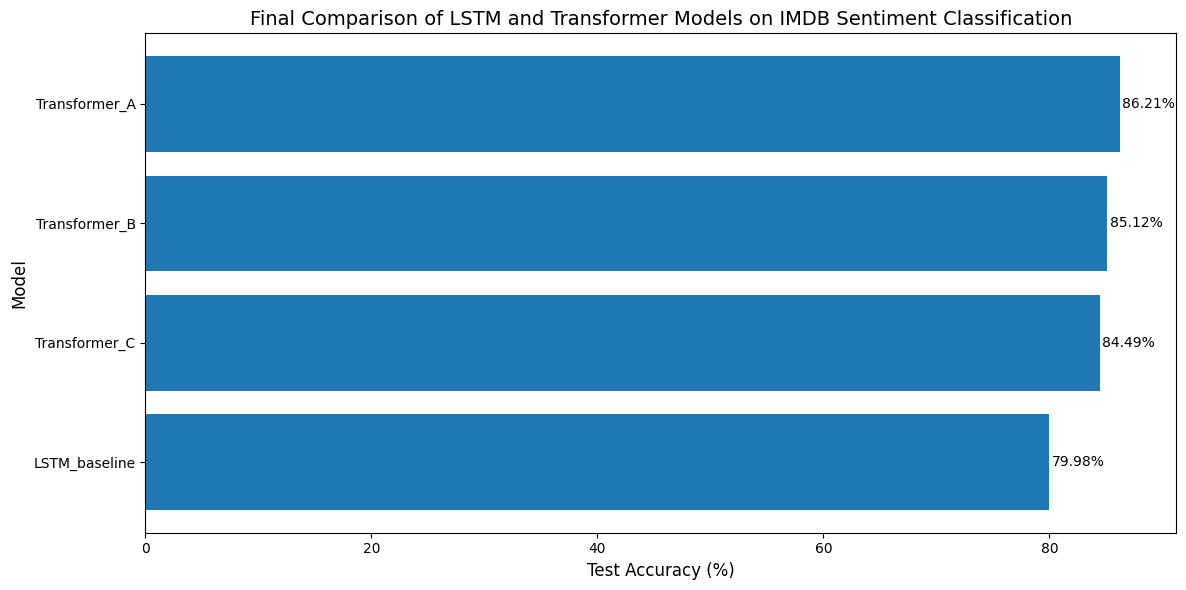

In [31]:
import matplotlib.pyplot as plt

# Sort for nicer plotting
plot_df = results_df.sort_values(by="Test Accuracy (%)", ascending=True)

plt.figure(figsize=(12, 6))
bars = plt.barh(plot_df["Model"], plot_df["Test Accuracy (%)"])

plt.xlabel("Test Accuracy (%)", fontsize=12)
plt.ylabel("Model", fontsize=12)
plt.title("Final Comparison of LSTM and Transformer Models on IMDB Sentiment Classification", fontsize=14)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, f"{width:.2f}%", va="center")

plt.xlim(0, max(plot_df["Test Accuracy (%)"]) + 5)
plt.tight_layout()
plt.show()